# 🥑 Module 3: The Voronoi Volume Game
### From 2D Spatial Partitioning to 3D Numerical Quadrature in the First Quadrant

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Jordi-Ab/inter-university-algorithms/main?labpath=voronoi-game%2FThe_Voronoi_Volume_Game.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jordi-Ab/inter-university-algorithms/blob/main/voronoi-game/The_Voronoi_Volume_Game.ipynb)
[![Python 3.11](https://img.shields.io/badge/python-3.11-blue.svg)](https://www.python.org/downloads/release/python-3110/)

---

## 🎯 Learning Journey: From 2D Area to 3D Volume

Welcome to the **Voronoi Volume Game**! This notebook guides you step-by-step through a journey from classical 2D computational geometry to 3D spatial economics and numerical integration:

1. **The 2D Voronoi Diagram**: Mathematical principles of distance metrics and spatial partitioning.
2. **Play the Classic 2D Game**: Interactive web game developed by PhD C.F. Brasz.
3. **The 1D Warm-Up**: Grasping territory stealing and Hotelling's law.
4. **Entering 3D: The "Blanket" over the Floor**: Understanding non-uniform density $f(x, y)$ as a curved ceiling above the flat unit square floor.
5. **The Interactive 3D Avocado Volume Game**: Playing the 6-seed match directly over the avocado density landscape.
6. **The "Corner Box-In" Trap & Winning Strategy**: Discovering why rushing to $(0, 0)$ can be fatal and how to balance density with territory.


In [1]:
# ==============================================================================
# Environment Setup & Package Imports
# ==============================================================================
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# Package import (installed via `pip install -e .` or `.binder/requirements.txt`)
# Includes graceful fallback for users running locally without package install
# ------------------------------------------------------------------------------
try:
    from voronoi_game import (
        VoronoiGame,
        PRESETS,
        StrategicAI,
        compute_bounded_voronoi,
        compute_delaunay_edges,
        validate_centers,
        summarize_cell_geometry,
        avocado_density,
        integrate_polygon,
        compute_cell_volumes,
        UNIT_SQUARE_TRUE_VOLUME,
        DENSITY_NORM_CONST,
        plot_voronoi_game_2d,
        plot_scoreboard_barchart,
        plot_voronoi_surface_3d,
        plot_dashboard,
        create_interactive_voronoi_widget,
        display_html_game,
        launch_game_in_browser,
    )
except ImportError:
    # Graceful fallback: dynamically locate voronoi-game folder
    for p in [os.path.abspath("."), os.path.abspath("voronoi-game"), os.path.abspath("../voronoi-game")]:
        if os.path.exists(os.path.join(p, "voronoi_geometry.py")) and p not in sys.path:
            sys.path.insert(0, p)
    from voronoi_geometry import compute_bounded_voronoi, compute_delaunay_edges, validate_centers, summarize_cell_geometry
    from numerical_integration import avocado_density, integrate_polygon, compute_cell_volumes, UNIT_SQUARE_TRUE_VOLUME, DENSITY_NORM_CONST
    from game_engine import VoronoiGame, PRESETS, StrategicAI
    from visuals import (
        plot_voronoi_game_2d, plot_scoreboard_barchart, plot_voronoi_surface_3d,
        plot_dashboard, create_interactive_voronoi_widget, display_html_game, launch_game_in_browser
    )

# Plot formatting
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CBD5E1'
plt.rcParams['axes.linewidth'] = 0.8

print("[OK] Voronoi Game package loaded successfully!")
print(f"     Avocado Density Peak at (0, 0): f_max = sqrt(3)/(4*pi) ~= {DENSITY_NORM_CONST:.6f}")
print(f"     Total Unit Square True Volume:  V_total ~= {UNIT_SQUARE_TRUE_VOLUME:.10f}")


[OK] Voronoi Game package loaded successfully!
     Avocado Density Peak at (0, 0): f_max = sqrt(3)/(4*pi) ~= 0.137832
     Total Unit Square True Volume:  V_total ~= 0.1127455796


---
## 🗺️ The 2D Voronoi Diagram & The Classic Area Game

### What is a Voronoi Diagram?
Given a set of $N$ generator points (called **seeds** or **sites**) in the plane $S = \{P_1, P_2, \dots, P_N\} \subset \mathbb{R}^2$, the **Voronoi diagram** partitions the plane into convex polygonal regions called **cells** $V(P_i)$:

$$V(P_i) = \left\{ x \in \mathbb{R}^2 : \|x - P_i\| \le \|x - P_j\| \quad \forall j \ne i \right\}$$

Every point $x$ inside cell $V(P_i)$ is closer to site $P_i$ than to any other site.  
The straight boundaries between adjacent cells are the **perpendicular bisectors** between neighboring pairs of points—lines of equal distance or economic **indifference lines**.

### The Classic Voronoi Area Game
In the classic game (studied by Ahn et al. 2004, Fekete & Meijer 2005):
* Two players (Red and Blue) take turns placing seeds inside a flat bounding box.
* Each player's payoff is simply the **geometric area** of the cells they control:
  $$\text{Payoff}(P_i) = \iint_{C_i} 1 \, dx \, dy = \text{Area}(C_i)$$
* The player controlling the most flat land area wins!


---
## 🕹️ Play the Classic 2D Voronoi Game

To experience the mechanics of the classic 2D area game, we have embedded below the celebrated interactive application created by C.F. Brasz ([`cfbrasz.github.io/VoronoiColoring.html`](https://cfbrasz.github.io/VoronoiColoring.html)):

* **How to Play**: Click anywhere on the white canvas to place seeds.
* **Observe**: As you move your mouse, see how the perpendicular bisectors dynamically reshape every cell on the board!
* 💡 **Tip**: If your local Jupyter/VS Code blocks embedded webviews, click the blue button below to open directly in a new browser tab!


In [2]:
# ------------------------------------------------------------------------------
# Embed the Classic 2D Voronoi Area Game (C.F. Brasz)
# ------------------------------------------------------------------------------
from IPython.display import IFrame, HTML, display

# Direct launch button + interactive canvas embed
display(HTML('''
<div style="margin-bottom: 10px;">
    <a href="https://cfbrasz.github.io/VoronoiColoring.html" target="_blank" 
       style="display: inline-block; background: #2563EB; color: #FFFFFF; padding: 8px 16px; border-radius: 8px; text-decoration: none; font-weight: 600; font-size: 13px;">
       🚀 Open cfbrasz.github.io in New Tab
    </a>
</div>
'''))
display(IFrame(src="https://cfbrasz.github.io/VoronoiColoring.html", width="100%", height=680))


---
## 📏 The 1D Warm-Up Experiment (Grasping Territory Stealing)

Before moving to 3D, let's build our strategic intuition with a simple 1D experiment:

> 💡 **Try this in the embedded game above:**
> 1. Check the box labeled **"Limit sites to one dimension"** (under Options).
> 2. Now, all seeds are constrained to lie along a single horizontal line segment $[0, L]$.
> 3. Click to place your first seed (Red) at the center $x = 0.5$.
> 4. Where does the computer (or Player 2) place its Blue seed?

### What Happens in 1D? (Hotelling's Law & Boundary Stealing)
If Player 1 places at $x = 0.5$, Player 2 will place immediately adjacent to Player 1, say at $x = 0.51$:
* The bisector between them falls at $x = 0.505$.
* Player 1 is left with only the left half $[0, 0.505]$ ($50.5\%$ of the line).
* Player 2 captures $[0.505, 1.0]$ ($49.5\%$ of the line).

If Player 1 instead placed at $x = 0.25$, Player 2 would place at $x = 0.26$, capturing **$74.5\%$ of the entire line** while leaving Player 1 with only $25.5\%$!

> 🔑 **Key Takeaway**: In Voronoi games, placing right next to an opponent lets you **steal their territory** by pushing the boundary right up against their point. Keep this in mind when we enter 3D!


---
## 🏔️ Entering the 3D World: The "Blanket" over the Floor

Now, imagine we leave the flat, sterile geometry behind and enter a real agricultural or economic market (as presented in the seminar *"A Voronoï volume game for the avocados"* by Dr. José Daniel López-Barrientos).

In the real world, **resource density and economic demand are NOT flat!**  
Some locations are prime farmland or dense urban centers, while others are barren deserts.

### The "Circus Tent / Mountain Blanket" Analogy

Think of the game as building rooms under a curved mountain:

1. **The Floor (The Map)**:  
   The game is played on the **flat unit square in the first quadrant**:
   $$\Omega = [0, 1] \times [0, 1] = \{(x, y) \in \mathbb{R}^2 : 0 \le x \le 1, \; 0 \le y \le 1\}$$
   with corners at $(0, 0)$, $(1, 0)$, $(1, 1)$, and $(0, 1)$.

2. **The Walls (Voronoi Bisectors)**:  
   When players place their 6 centers $P_1, \dots, P_6$, standard perpendicular bisectors chop the flat floor into **6 polygon rooms / cells** $C_1, \dots, C_6$.

3. **The Curved Roof (The Blanket)**:  
   Above the floor hangs a curved ceiling—the **avocado density function**:
   $$f(x, y) = \frac{\sqrt{3}}{4\pi} \exp\left(-\frac{x^2 - xy + y^2}{2}\right)$$
   * Right above the origin $(0, 0)$, the blanket reaches its **highest peak**: $f(0, 0) = \frac{\sqrt{3}}{4\pi} \approx 0.138$. This is the **Avocado Goldmine**!
   * As you walk away towards $(1, 1)$, the blanket slopes downward towards zero.

4. **The Score (The 3D Volume)**:  
   A player's harvest (payoff) is NOT their flat land area. It is the **physical 3D volume trapped inside their room under the curved roof**:
   $$\text{Payoff}(P_i) = \iint_{C_i} f(x, y) \, dx \, dy$$

Let's visualize the 2D contour map and the 3D mountain surface in Python!


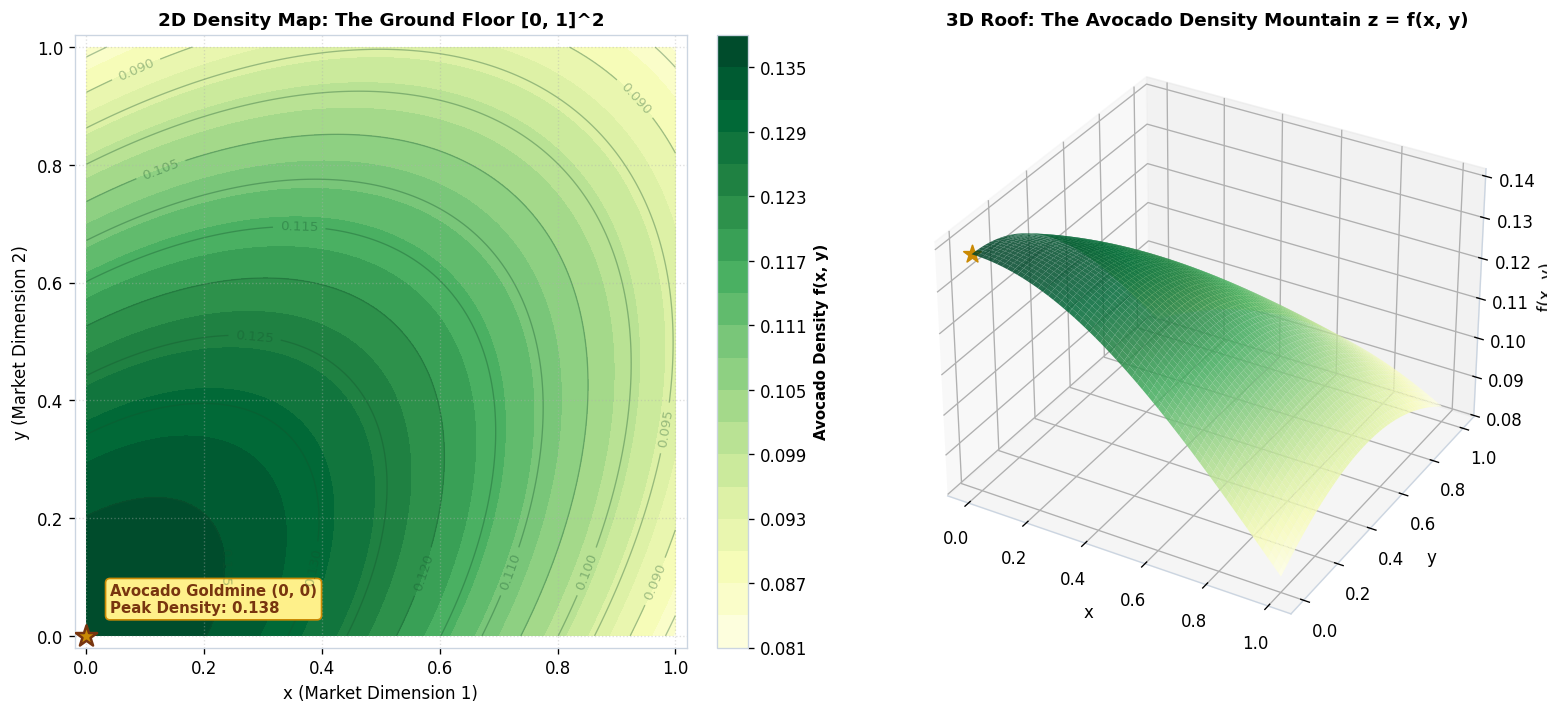

In [3]:
# ------------------------------------------------------------------------------
# Visualizing the Avocado Density Blanket: 2D Contour Map & 3D Mountain
# ------------------------------------------------------------------------------
res = 120
x_vals = np.linspace(0, 1, res)
y_vals = np.linspace(0, 1, res)
X, Y = np.meshgrid(x_vals, y_vals)
Z = avocado_density(X, Y)

fig = plt.figure(figsize=(14, 6))

# Left: 2D Contour Heatmap
ax1 = fig.add_subplot(1, 2, 1)
cf = ax1.contourf(X, Y, Z, levels=20, cmap="YlGn")
cbar = plt.colorbar(cf, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label("Avocado Density f(x, y)", fontsize=9, fontweight="semibold")
cl = ax1.contour(X, Y, Z, levels=10, colors="#14532D", alpha=0.35, linewidths=0.8)
ax1.clabel(cl, inline=True, fontsize=8, fmt="%.3f")

# Origin goldmine callout
ax1.scatter([0], [0], s=180, color="#CA8A04", marker="*", edgecolor="#78350F", linewidth=1.5, zorder=5)
ax1.annotate("Avocado Goldmine (0, 0)\nPeak Density: 0.138", xy=(0.04, 0.04), fontsize=9, fontweight="bold",
             color="#78350F", bbox=dict(boxstyle="round,pad=0.3", facecolor="#FEF08A", edgecolor="#CA8A04"))
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.02, 1.02)
ax1.set_aspect("equal")
ax1.set_title("2D Density Map: The Ground Floor [0, 1]^2", fontsize=11, fontweight="bold")
ax1.set_xlabel("x (Market Dimension 1)")
ax1.set_ylabel("y (Market Dimension 2)")
ax1.grid(True, linestyle=":", alpha=0.4)

# Right: 3D Perspective Mountain Surface
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
surf = ax2.plot_surface(X, Y, Z, cmap="YlGn", alpha=0.85, rstride=2, cstride=2, edgecolor="none")
ax2.scatter([0], [0], [DENSITY_NORM_CONST], color="#CA8A04", s=120, marker="*")
ax2.set_title("3D Roof: The Avocado Density Mountain z = f(x, y)", fontsize=11, fontweight="bold")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x, y)")
ax2.view_init(elev=32, azim=-60)

plt.tight_layout()
plt.show()


---
## 🎮 The Interactive 3D Avocado Volume Game

Now, let's play the game with the **curved avocado blanket** enabled! This HTML was developed by taking the celebrated interactive application created by C.F. Brasz ([`cfbrasz.github.io/VoronoiColoring.html`](https://cfbrasz.github.io/VoronoiColoring.html)) as reference.

Play the click-to-place canvas game with real-time simplicial cubature, dual scoreboards (Volume vs Area), and 1-click clipboard export!

You can play 1v1 or against a computer.


In [5]:
# ------------------------------------------------------------------------------
# Mode B: Standalone 60-FPS HTML5 Canvas Game (Click-to-Place & Dual Scoreboard)
# ------------------------------------------------------------------------------
# Embeds the HTML5 canvas game directly below with a dedicated browser launch button:
# (You can also call `launch_game_in_browser()` to open it in a full browser window)
display_html_game()


---
## 🥊 The "Corner Box-In" Trap & The Winning Strategy

Now that you have played the game, let's analyze the deep strategic trap that catches almost every first-time player:

### 🪤 The Trap: The Fatal Rush to (0, 0)
When students learn that the peak of the mountain is at $(0, 0)$, their immediate instinct is:
> *"I should place my first seed right on the peak at $(0.05, 0.05)$!"*

**Why this is a fatal mistake:**
1. The origin $(0, 0)$ is in the **corner** of the board. Your back is against two impassable boundary walls: $x = 0$ and $y = 0$.
2. Your opponent responds by placing their seed right in front of you at **$(0.15, 0.15)$**.
3. The perpendicular bisector between $(0.05, 0.05)$ and $(0.15, 0.15)$ cuts you off completely, **hemming you into a microscopic triangle in the corner**!
4. Even though your corner has the highest density, its physical area is so tiny that:
   $$\text{Volume} = \text{High Density} \times \text{Tiny Area} \approx 0!$$
5. Meanwhile, your opponent captures all the rest of the mountain slope *plus* $95\%$ of the board!

---

### 🏆 The Winning Strategy: Balancing Density with Territory
To maximize your volume score, you must balance **Density** AND **Area**:
$$\text{Score} = \iint_{C_i} f(x, y) \, dx \, dy$$

1. **Power Projection**: Place far enough away from the corner walls (e.g. around $(0.20, 0.20)$) so that your cell expands outward and controls a wide swath of the high-density mountain.
2. **Denying the Goldmine**: By placing around $(0.20, 0.20)$, you are close enough to the peak that your opponent cannot slip behind you into the corner without getting quarantined or receiving a minuscule sliver.
3. **Flanking Moves**: Use your second and third seeds to guard the $(x=0)$ and $(y=0)$ boundaries, sealing off access to the origin!


### 📚 References & Further Reading
1. **López-Barrientos, J. D., Flores Herrera, A. P., Fernández-Arias, E., & Escobedo-Trujillo, B. A. (2025).** *Proposals to Transfer Risks in Avocado Load.* Revista Mexicana de Economía y Finanzas (REMEF), 20(2), 959.
2. **Kumar, V. S., & Kumaran, V. (2005).** *Voronoi cell volume distribution and configurational entropy of hard-spheres.* Journal of Chemical Physics, 123(11).
3. **Hoffman, C. E., Holroyd, A. E., & Peres, Y. (2006).** *A stable marriage of Poisson and Lebesgue.* Annals of Probability, 34(4), 1241–1272.
4. **Aurenhammer, F., Klein, R., & Lee, D.-T. (2013).** *Voronoi Diagrams and Delaunay Triangulation.* World Scientific.
